# Happy Customers — Apziva Project 1

This notebook presents the complete analysis for predicting customer happiness from six survey questions. It includes data exploration, model comparison, hyperparameter tuning, final evaluation, permutation feature importance, and feature-subset analysis.

In [1]:
from itertools import combinations
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    f1_score, precision_score, recall_score,
)
from sklearn.model_selection import (
    GridSearchCV, RepeatedStratifiedKFold, StratifiedKFold,
    cross_validate, train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42

# This notebook is expected to live inside notebooks/.
project_folder = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_file = project_folder / "data" / "raw" / "ACME-HappinessSurvey2020.xlsx"
reports_folder = project_folder / "reports"
figures_folder = reports_folder / "figures"
models_folder = project_folder / "models"

reports_folder.mkdir(parents=True, exist_ok=True)
figures_folder.mkdir(parents=True, exist_ok=True)
models_folder.mkdir(parents=True, exist_ok=True)

print("Project folder:", project_folder)
print("Looking for data at:", data_file)
print("File exists:", data_file.exists())


Project folder: c:\Users\saeed\Documents\Apziva\project 1\wW3Y6TuEBcZyqkBS
Looking for data at: c:\Users\saeed\Documents\Apziva\project 1\wW3Y6TuEBcZyqkBS\data\raw\ACME-HappinessSurvey2020.xlsx
File exists: True


## 1. Load and explore the data


In [2]:
features = ["X1", "X2", "X3", "X4", "X5", "X6"]
question_names = {
    "X1": "Order delivered on time",
    "X2": "Contents were as expected",
    "X3": "Ordered everything wanted",
    "X4": "Paid a good price",
    "X5": "Satisfied with courier",
    "X6": "App makes ordering easy",
}

data = pd.read_excel(data_file)

display(data.head())
print("Dataset shape:", data.shape)
print("Missing values:", data.isna().sum().sum())
print("Duplicate rows:", data.duplicated().sum())
print("\nTarget counts (0 = unhappy, 1 = happy):")
display(data["Y"].value_counts().sort_index())
print("\nSurvey answer summary:")
display(data[features].describe().round(2))

if list(data.columns) != ["Y"] + features:
    raise ValueError("The file should contain Y followed by X1 to X6.")
if data.isna().any().any():
    raise ValueError("The dataset contains missing values.")
if not data["Y"].isin([0, 1]).all():
    raise ValueError("Y should contain only 0 and 1.")
if not data[features].apply(lambda column: column.between(1, 5)).all().all():
    raise ValueError("Answers in X1 to X6 should be between 1 and 5.")


,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


Dataset shape: (126, 7)
Missing values: 0
Duplicate rows: 16

Target counts (0 = unhappy, 1 = happy):


Y
0    57
1    69
Name: count, dtype: int64


Survey answer summary:


,X1,X2,X3,X4,X5,X6
count,126.00,126.00,126.00,126.00,126.00,126.00
mean,4.33,2.53,3.31,3.75,3.65,4.25
std,0.80,1.11,1.02,0.88,1.15,0.81
min,1.00,1.00,1.00,1.00,1.00,1.00
25%,4.00,2.00,3.00,3.00,3.00,4.00
50%,5.00,3.00,3.00,4.00,4.00,4.00
75%,5.00,3.00,4.00,4.00,4.00,5.00
max,5.00,5.00,5.00,5.00,5.00,5.00


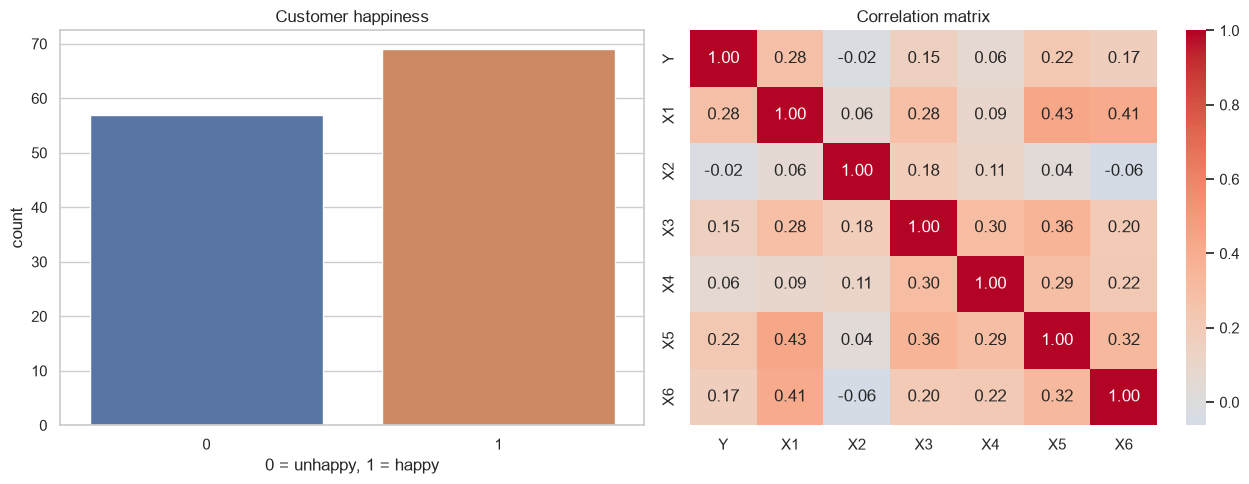

In [3]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=data, x="Y", hue="Y", legend=False, ax=axes[0])
axes[0].set_title("Customer happiness")
axes[0].set_xlabel("0 = unhappy, 1 = happy")

sns.heatmap(data.corr(), annot=True, cmap="coolwarm", center=0,
            fmt=".2f", ax=axes[1])
axes[1].set_title("Correlation matrix")

fig.tight_layout()
fig.savefig(figures_folder / "data_overview.png", dpi=200, bbox_inches="tight")
plt.show()


## 2. Prepare training and test data


In [4]:
X = data[features]
y = data["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))


Training rows: 100
Test rows: 26


## 3. Compare classification models


In [5]:
models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=2000, class_weight="balanced",
            random_state=RANDOM_STATE
        ),
    ),
    "Support Vector Machine": make_pipeline(
        StandardScaler(),
        SVC(class_weight="balanced", random_state=RANDOM_STATE),
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
}

model_cv = RepeatedStratifiedKFold(
    n_splits=5, n_repeats=10, random_state=RANDOM_STATE
)

model_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=model_cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
        },
    )

    model_results.append({
        "Model": model_name,
        "Accuracy mean": scores["test_accuracy"].mean(),
        "Accuracy std": scores["test_accuracy"].std(),
        "Precision mean": scores["test_precision"].mean(),
        "Recall mean": scores["test_recall"].mean(),
        "F1 mean": scores["test_f1"].mean(),
        "F1 std": scores["test_f1"].std(),
    })

model_results = pd.DataFrame(model_results).sort_values(
    ["F1 mean", "Accuracy mean"], ascending=False
)

model_results.to_csv(reports_folder / "model_comparison.csv", index=False)
display(model_results.round(3))

best_cv_model_name = model_results.iloc[0]["Model"]
print("Best model by mean CV F1:", best_cv_model_name)


,Model,Accuracy mean,Accuracy std,Precision mean,Recall mean,F1 mean,F1 std
3,Gradient Boosting,0.541,0.101,0.581,0.624,0.595,0.099
0,Logistic Regression,0.549,0.104,0.594,0.596,0.588,0.107
2,Random Forest,0.541,0.092,0.588,0.587,0.580,0.095
1,Support Vector Machine,0.525,0.085,0.567,0.564,0.557,0.111


Best model by mean CV F1: Gradient Boosting


## 4. Tune Gradient Boosting

Gradient Boosting achieved the highest mean F1 score during the model comparison, so it was selected for hyperparameter tuning.


In [6]:
parameter_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.10],
    "max_depth": [1, 2, 3],
    "min_samples_leaf": [1, 3, 5],
}

tuning_cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    parameter_grid,
    scoring="f1",
    cv=tuning_cv,
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

joblib.dump(best_model, models_folder / "gradient_boosting_model.joblib")

print("Best Gradient Boosting parameters:")
print(grid_search.best_params_)
print(f"Best tuning F1 score: {grid_search.best_score_:.3f}")


Best Gradient Boosting parameters:
{'learning_rate': 0.01, 'max_depth': 2, 'min_samples_leaf': 1, 'n_estimators': 50}
Best tuning F1 score: 0.669


## 5. Final evaluation on the untouched test set


In [7]:
test_predictions = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_predictions)
test_precision = precision_score(y_test, test_predictions, zero_division=0)
test_recall = recall_score(y_test, test_predictions, zero_division=0)
test_f1 = f1_score(y_test, test_predictions, zero_division=0)

final_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 score"],
    "Value": [test_accuracy, test_precision, test_recall, test_f1],
})

display(final_metrics.round(3))

print(classification_report(
    y_test,
    test_predictions,
    target_names=["Unhappy", "Happy"],
    zero_division=0,
))


,Metric,Value
0,Accuracy,0.731
1,Precision,0.667
2,Recall,1.000
3,F1 score,0.800


              precision    recall  f1-score   support

     Unhappy       1.00      0.42      0.59        12
       Happy       0.67      1.00      0.80        14

    accuracy                           0.73        26
   macro avg       0.83      0.71      0.69        26
weighted avg       0.82      0.73      0.70        26



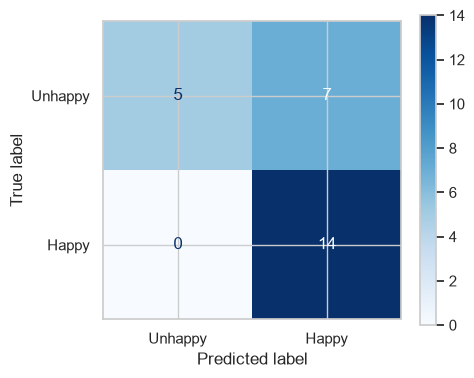

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["Unhappy", "Happy"],
    cmap="Blues",
    ax=ax,
)
fig.tight_layout()
fig.savefig(figures_folder / "confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


## 6. Permutation feature importance


In [9]:
importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=100,
    random_state=RANDOM_STATE,
)

importance_table = pd.DataFrame({
    "Feature": features,
    "Question": [question_names[feature] for feature in features],
    "Importance mean": importance.importances_mean,
    "Importance std": importance.importances_std,
}).sort_values("Importance mean", ascending=False)

importance_table.to_csv(reports_folder / "feature_importance.csv", index=False)
display(importance_table.round(3))


,Feature,Question,Importance mean,Importance std
0,X1,Order delivered on time,0.083,0.034
5,X6,App makes ordering easy,0.077,0.029
2,X3,Ordered everything wanted,0.019,0.024
1,X2,Contents were as expected,0.000,0.000
3,X4,Paid a good price,0.000,0.000
4,X5,Satisfied with courier,0.000,0.000


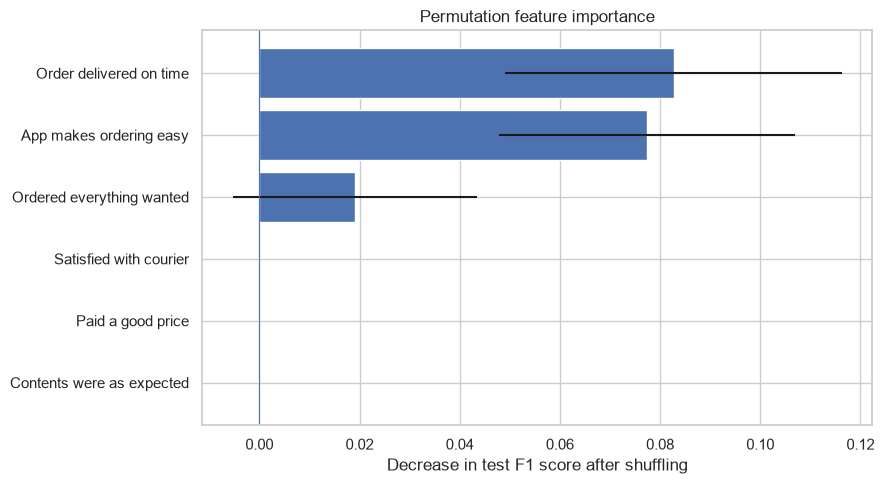

In [10]:
plot_data = importance_table.sort_values("Importance mean")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    plot_data["Question"],
    plot_data["Importance mean"],
    xerr=plot_data["Importance std"],
)
ax.axvline(0, linewidth=0.8)
ax.set_title("Permutation feature importance")
ax.set_xlabel("Decrease in test F1 score after shuffling")
fig.tight_layout()
fig.savefig(figures_folder / "feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()


## 7. Test smaller groups of survey questions


In [11]:
subset_cv = RepeatedStratifiedKFold(
    n_splits=5, n_repeats=5, random_state=RANDOM_STATE
)

subset_results = []

for number_of_features in range(1, len(features) + 1):
    print(f"Testing subsets containing {number_of_features} feature(s)...")

    for subset in combinations(features, number_of_features):
        subset = list(subset)

        scores = cross_validate(
            clone(best_model),
            X_train[subset],
            y_train,
            cv=subset_cv,
            scoring={"accuracy": "accuracy", "f1": "f1"},
        )

        subset_results.append({
            "Number of features": number_of_features,
            "Features": ", ".join(subset),
            "CV accuracy": scores["test_accuracy"].mean(),
            "CV F1": scores["test_f1"].mean(),
            "CV F1 std": scores["test_f1"].std(),
        })

subset_results = pd.DataFrame(subset_results)

subset_results["Combined score"] = (
    subset_results["CV accuracy"] + subset_results["CV F1"]
) / 2

subset_results = subset_results.sort_values(
    ["Combined score", "Number of features"],
    ascending=[False, True],
)

subset_results.to_csv(
    reports_folder / "feature_subset_results.csv",
    index=False,
)

display(subset_results.head().round(3))


Testing subsets containing 1 feature(s)...
Testing subsets containing 2 feature(s)...
Testing subsets containing 3 feature(s)...
Testing subsets containing 4 feature(s)...
Testing subsets containing 5 feature(s)...
Testing subsets containing 6 feature(s)...


,Number of features,Features,CV accuracy,CV F1,CV F1 std,Combined score
10,2,"X1, X6",0.598,0.717,0.086,0.657
27,3,"X1, X3, X6",0.588,0.702,0.099,0.645
24,3,"X1, X2, X6",0.578,0.706,0.060,0.642
3,1,X4,0.562,0.709,0.025,0.636
43,4,"X1, X2, X3, X6",0.568,0.694,0.078,0.631


## 8. Final project summary


In [12]:
best_subset = subset_results.iloc[0]
selected_features = best_subset["Features"].split(", ")
questions_to_remove = sorted(set(features) - set(selected_features))

print("Recommended features:", best_subset["Features"])
print("Possible questions to remove:", ", ".join(questions_to_remove) or "None")

final_summary = pd.DataFrame([{
    "Selected model": "Gradient Boosting",
    "Test accuracy": test_accuracy,
    "Test precision": test_precision,
    "Test recall": test_recall,
    "Test F1": test_f1,
    "Recommended features": best_subset["Features"],
    "Subset CV accuracy": best_subset["CV accuracy"],
    "Subset CV F1": best_subset["CV F1"],
}])

final_summary.to_csv(reports_folder / "final_summary.csv", index=False)
display(final_summary.round(3))


Recommended features: X1, X6
Possible questions to remove: X2, X3, X4, X5


,Selected model,Test accuracy,Test precision,Test recall,Test F1,Recommended features,Subset CV accuracy,Subset CV F1
0,Gradient Boosting,0.731,0.667,1.0,0.8,"X1, X6",0.598,0.717


### Interpretation

The feature-subset result is an initial modelling finding, not a final business decision. Because the dataset is small, more customer responses should be collected before permanently removing survey questions.
